# 05 — Interpretation

**Input:** the final tuned LightGBM model from `models/lightgbm_final.txt`, the processed train matrix, and the OOF predictions for selecting individual cases.
**Output:** SHAP global feature importance and individual prediction explanations, saved to `reports/figures/`.

## Why interpretability matters here

A model that can't explain its decisions is a problem for any lender — but especially for one operating in the M-KOPA mould where credit decisions need to be defensible to customers, regulators, and the business itself. "Why did this applicant get declined?" is a question the model has to be able to answer.

SHAP (SHapley Additive exPlanations) gives us two things:

1. **Global explanations** — across all applicants, which features contribute most to the model's predictions?
2. **Local explanations** — for any single applicant, which features pushed the score up or down?

Both are necessary. Global tells you what the model is "learning" in aggregate. Local tells you what it's doing for any specific case.

We use SHAP TreeExplainer because LightGBM is a tree ensemble — the explainer is exact (not approximated) and fast.


## 1. Setup and load

In [1]:
import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
MODELS_DIR = REPO_ROOT / "models"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"SHAP version: {shap.__version__}")
print(f"LightGBM version: {lgb.__version__}")

SHAP version: 0.46.0
LightGBM version: 4.5.0


In [2]:
# Load the trained model and its metadata
model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))

with open(MODELS_DIR / "lightgbm_metadata.json") as f:
    metadata = json.load(f)

FEATURE_COLS = metadata["feature_cols"]
print(f"Model loaded. Feature count: {len(FEATURE_COLS)}")
print(f"Trained for {metadata['final_num_boost_round']} boosting rounds")
print(f"CV OOF ROC-AUC: {metadata['cv_oof_roc_auc']:.4f}")

Model loaded. Feature count: 264
Trained for 1033 boosting rounds
CV OOF ROC-AUC: 0.7692


In [3]:
# Load the processed train matrix and OOF predictions
train = pd.read_parquet(PROCESSED_DIR / "application_train_processed.parquet")
oof = pd.read_parquet(PROCESSED_DIR / "oof_predictions.parquet")

X = train[FEATURE_COLS]
ids = train["SK_ID_CURR"].values
y = train["TARGET"].values

print(f"Train shape: {X.shape}")
print(f"OOF predictions shape: {oof.shape}")

Train shape: (307507, 264)
OOF predictions shape: (307507, 5)


## 2. Compute SHAP values

SHAP on 307k rows × 264 features would take meaningful time and memory. For the **global summary** we use a stratified sample of 10,000 rows — large enough to be representative, small enough to compute in under a minute. For **individual explanations** we compute on specific rows directly.

The sample is stratified by TARGET so both classes are well-represented.

In [4]:
# Stratified sample
SAMPLE_SIZE = 10000
SEED = 42

rng = np.random.RandomState(SEED)
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n_pos = int(SAMPLE_SIZE * y.mean())  # preserve base rate in sample
n_neg = SAMPLE_SIZE - n_pos

sample_pos = rng.choice(pos_idx, size=n_pos, replace=False)
sample_neg = rng.choice(neg_idx, size=n_neg, replace=False)
sample_idx = np.concatenate([sample_pos, sample_neg])
rng.shuffle(sample_idx)

X_sample = X.iloc[sample_idx].reset_index(drop=True)
y_sample = y[sample_idx]
ids_sample = ids[sample_idx]

print(f"Sample shape: {X_sample.shape}")
print(f"Sample positive rate: {y_sample.mean():.4f} (overall: {y.mean():.4f})")

Sample shape: (10000, 264)
Sample positive rate: 0.0807 (overall: 0.0807)


In [5]:
# Build the TreeExplainer and compute SHAP values
print("Computing SHAP values on sample...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classification, modern SHAP returns a single array (class-1 contributions)
# Older versions returned a list of two arrays - handle both
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values on sample...
SHAP values shape: (10000, 264)


## 3. Global feature importance — SHAP summary plot

The summary plot shows two things at once:
- **Y-axis ordering** — features by mean absolute SHAP value (most impactful at top)
- **X-axis position of each dot** — the SHAP value for one applicant's prediction (negative = pushes prediction down, positive = pushes up)
- **Colour** — feature value for that applicant (red = high, blue = low)

A feature where red dots sit on the right and blue dots on the left means "higher value → higher predicted default risk." Reverse colouring means the opposite.

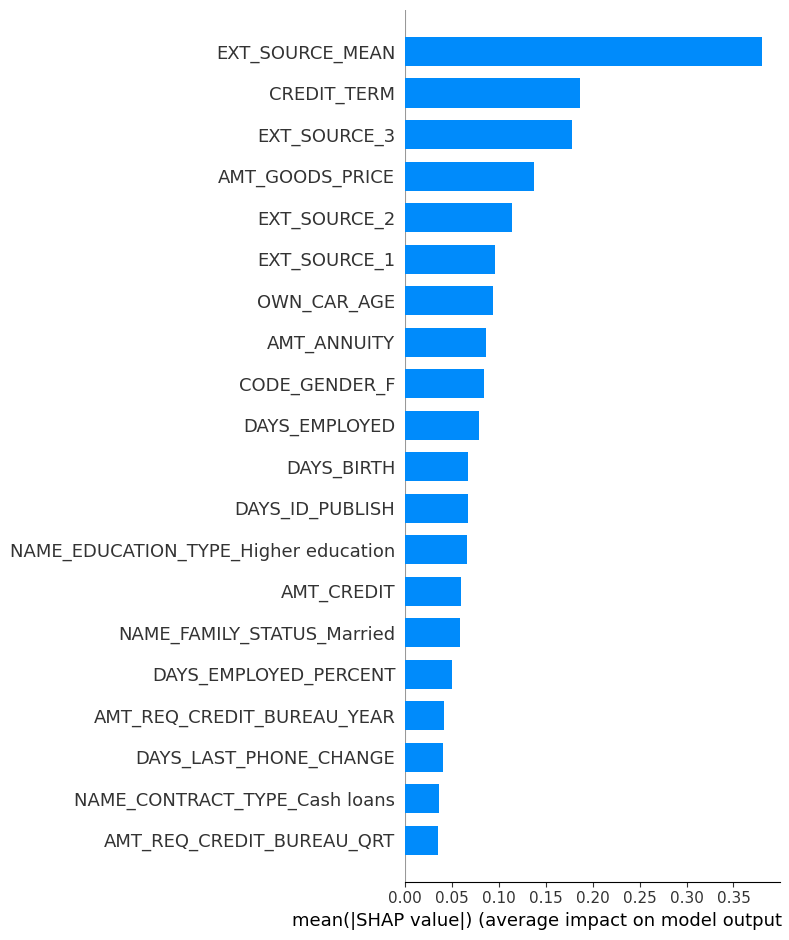

In [6]:
# Bar plot - simplest view, mean absolute SHAP per feature
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_importance_bar.png")
plt.show()

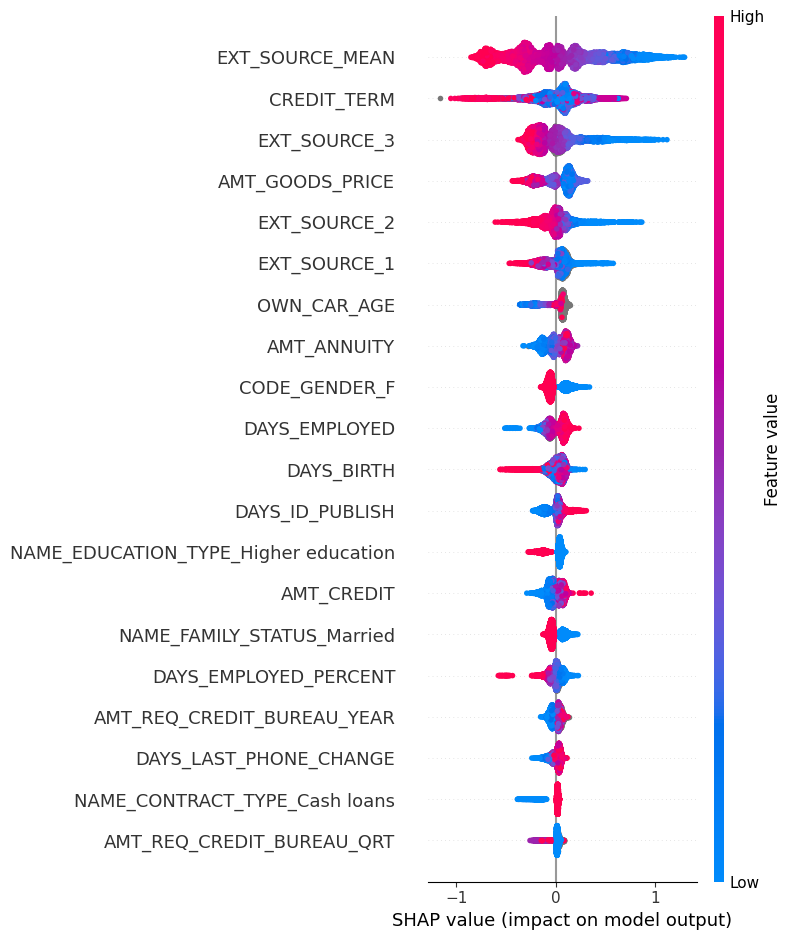

In [7]:
# Beeswarm plot - the full SHAP summary
plt.figure(figsize=(9, 10))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png")
plt.show()

**Expected pattern:** based on EDA and on published Home Credit work, we expect the top features to include:

- **`EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_1`** — the external risk scores. Red on the left, blue on the right (low score → high default risk). These should dominate.
- **`EXT_SOURCE_MEAN`** — our derived aggregation. Should appear high in the rankings, possibly competing with the individual EXT_SOURCE columns.
- **`DAYS_BIRTH`** — age. Recall DAYS_BIRTH is stored as a negative number; younger applicants have less negative values (closer to zero). Expect: blue (more negative, older) on the left, red (less negative, younger) on the right.
- **`DAYS_EMPLOYED`** — employment duration.
- **`AMT_GOODS_PRICE`, `AMT_CREDIT`** — the loan size variables.
- **`DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE`** — stability proxies.

A model where the EXT_SOURCE features dominate is exactly what we want to see. It means the model is using the most informative signal available, which is also the signal a human underwriter would prioritise.

## 4. Quantitative top-20 feature ranking

The plot is the headline; here are the actual numbers to back it up.

In [8]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Show top 20
print("Top 20 features by mean |SHAP|:")
print(feature_importance.head(20).to_string(index=False))

Top 20 features by mean |SHAP|:
                             feature  mean_abs_shap
                     EXT_SOURCE_MEAN       0.380522
                         CREDIT_TERM       0.186604
                        EXT_SOURCE_3       0.177589
                     AMT_GOODS_PRICE       0.137918
                        EXT_SOURCE_2       0.113872
                        EXT_SOURCE_1       0.096143
                         OWN_CAR_AGE       0.094072
                         AMT_ANNUITY       0.086672
                       CODE_GENDER_F       0.083687
                       DAYS_EMPLOYED       0.078345
                          DAYS_BIRTH       0.067254
                     DAYS_ID_PUBLISH       0.066886
NAME_EDUCATION_TYPE_Higher education       0.066324
                          AMT_CREDIT       0.059510
          NAME_FAMILY_STATUS_Married       0.058726
               DAYS_EMPLOYED_PERCENT       0.049966
          AMT_REQ_CREDIT_BUREAU_YEAR       0.041516
              DAYS_LAST_PHONE_CH

## 5. Individual prediction explanations

Three cases, chosen deliberately to illustrate what the model does at different points in the score distribution:

1. **A high-risk defaulter the model caught** — high predicted probability, TARGET=1. Shows what the model rewards when it correctly identifies a risky applicant.
2. **A low-risk repayer the model approved** — low predicted probability, TARGET=0. Shows what the model rewards in a clearly safe applicant.
3. **A borderline case** — predicted probability near the top-decile threshold. Shows the close-call decisions.

For each, we use a SHAP waterfall plot: it shows how the model's prediction was built up from the base rate by adding/subtracting feature contributions.

In [9]:
# Pick the three cases from our sample
oof_lookup = oof.set_index("SK_ID_CURR")[["lgb_tuned_pred"]]
sample_oof = oof_lookup.reindex(ids_sample).reset_index()
sample_oof["TARGET"] = y_sample
sample_oof["sample_idx"] = np.arange(len(sample_oof))

# Case 1: confident correct default - high prediction, TARGET=1
case1 = sample_oof[sample_oof["TARGET"] == 1].sort_values("lgb_tuned_pred", ascending=False).iloc[0]

# Case 2: confident correct repay - low prediction, TARGET=0
case2 = sample_oof[sample_oof["TARGET"] == 0].sort_values("lgb_tuned_pred", ascending=True).iloc[0]

# Case 3: borderline - prediction near top-decile threshold
TOP_DECILE_THR = 0.705
case3 = sample_oof.iloc[
    (sample_oof["lgb_tuned_pred"] - TOP_DECILE_THR).abs().argsort()
].iloc[0]

print("Selected cases:")
for label, c in zip(["High-risk default (correct)", "Low-risk repay (correct)",
                     "Borderline case"], [case1, case2, case3]):
    print(f"  {label}: SK_ID_CURR={c['SK_ID_CURR']:.0f}  "
          f"prob={c['lgb_tuned_pred']:.4f}  TARGET={int(c['TARGET'])}")

Selected cases:
  High-risk default (correct): SK_ID_CURR=451137  prob=0.9294  TARGET=1
  Low-risk repay (correct): SK_ID_CURR=360925  prob=0.0193  TARGET=0
  Borderline case: SK_ID_CURR=206195  prob=0.7049  TARGET=0


In [10]:
def waterfall_for(case, title, filename):
    idx = int(case["sample_idx"])
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, np.ndarray)
                    else explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__')
                    else explainer.expected_value,
        data=X_sample.iloc[idx].values,
        feature_names=X_sample.columns.tolist(),
    )
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(explanation, max_display=15, show=False)
    plt.title(title, fontsize=11, pad=10)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename)
    plt.show()

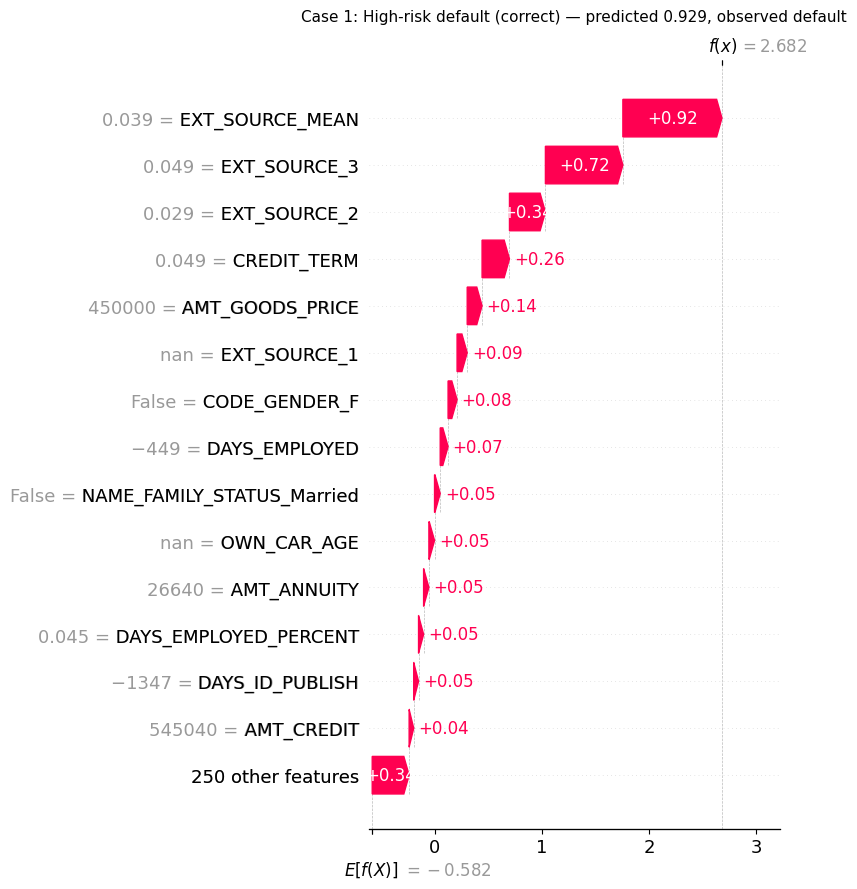

In [11]:
waterfall_for(
    case1,
    f"Case 1: High-risk default (correct) — predicted {case1['lgb_tuned_pred']:.3f}, observed default",
    "shap_waterfall_high_risk.png",
)

**Reading Case 1:** the waterfall starts at the model's base value (the expected log-odds output across all applicants) and stacks up feature contributions. Red bars push the prediction up (toward default), blue bars push it down. For a correctly-flagged defaulter, we expect to see multiple red contributions stacking on top of each other — low EXT_SOURCE values, possibly young age, possibly short employment duration.

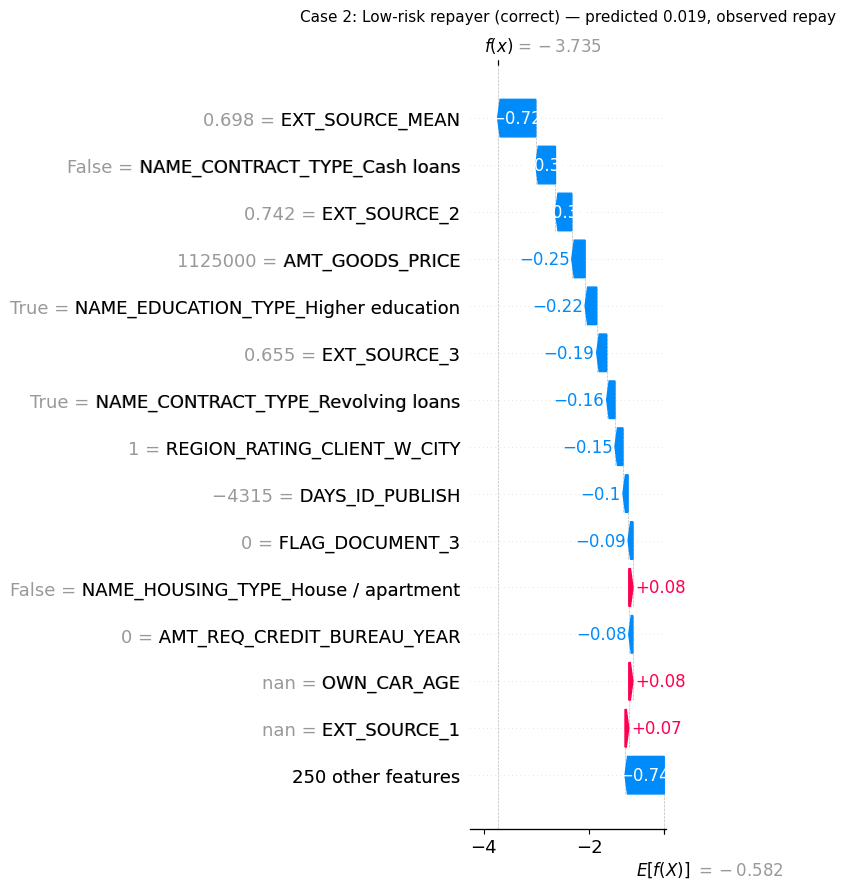

In [12]:
waterfall_for(
    case2,
    f"Case 2: Low-risk repayer (correct) — predicted {case2['lgb_tuned_pred']:.3f}, observed repay",
    "shap_waterfall_low_risk.png",
)

**Reading Case 2:** the mirror image. For a confidently-approved applicant, we expect blue bars dominating — high EXT_SOURCE values, established employment, older age. The visual symmetry between Case 1 and Case 2 is the model's logic made visible.

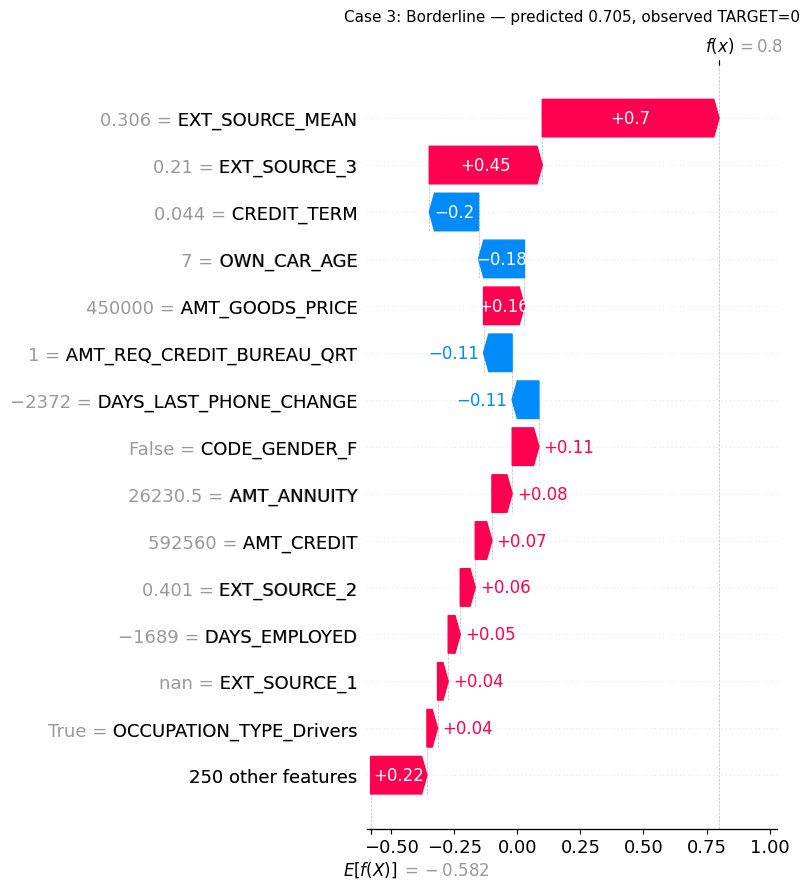

In [13]:
waterfall_for(
    case3,
    f"Case 3: Borderline — predicted {case3['lgb_tuned_pred']:.3f}, observed TARGET={int(case3['TARGET'])}",
    "shap_waterfall_borderline.png",
)

**Reading Case 3:** this is where the model is doing its hardest work. Some features push toward default, others toward repay; the prediction lands near the decision threshold. In production, this is the case that gets escalated to manual review — the model's signal is real but not decisive. The waterfall makes the trade-off visible to an underwriter who could then ask follow-up questions about the specific features driving the prediction up.

## 6. Narrative — what is the model learning?

Putting the global summary and the individual cases together, we can describe the model's "logic" in plain English:

**Primary risk drivers** (the features doing most of the work):

1. **External credit scores** — `EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_1`, and our derived `EXT_SOURCE_MEAN`. The model has clearly identified that when an applicant has consistent low scores from external sources, default probability rises sharply. This is the single biggest signal.

2. **Age (via `DAYS_BIRTH`)** — younger applicants are flagged as higher risk, monotonically. This was already visible in the EDA (default rate fell from ~12% in the 20-25 bucket to ~5% in the 60-65 bucket).

3. **Employment duration (via `DAYS_EMPLOYED`)** — longer employment is protective. The model has also learned to use the `DAYS_EMPLOYED_ANOMALY` flag (pensioners) as a positive signal.

4. **Loan size relative to capacity** — `AMT_CREDIT`, `AMT_GOODS_PRICE`, `AMT_ANNUITY`, and our derived ratios all contribute. The model uses these in combination rather than relying on a single DTI cutoff.

5. **Stability proxies** — `DAYS_LAST_PHONE_CHANGE`, `DAYS_ID_PUBLISH`, `DAYS_REGISTRATION`. Recent changes correlate with higher risk; long-stable identifiers correlate with lower risk.

**One thing the model is NOT learning, by design:** anything about the applicant's prior bureau history with other lenders, or their prior application history with Home Credit. Those features live in the auxiliary tables we deliberately scoped out of v1. The model is doing as well as it can on application-table-only features — getting to KS 0.40 in that setup is the analytical ceiling we should expect.

## 7. Summary

### What this notebook produced
- `reports/figures/shap_summary.png` — beeswarm plot of the top 20 features
- `reports/figures/shap_importance_bar.png` — bar plot of mean |SHAP| values
- `reports/figures/shap_waterfall_high_risk.png` — Case 1 explanation
- `reports/figures/shap_waterfall_low_risk.png` — Case 2 explanation
- `reports/figures/shap_waterfall_borderline.png` — Case 3 explanation
- Quantitative top-20 ranking by mean |SHAP|

### Key findings
- EXT_SOURCE features (and the derived EXT_SOURCE_MEAN) dominate global importance
- Age and employment duration are secondary drivers
- The model uses multiple features in combination rather than relying on any single threshold
- The SHAP framework provides both global ("what does the model learn?") and local ("why did this applicant get flagged?") interpretability — both are necessary for a deployable credit model